<a href="https://colab.research.google.com/github/Jerefilms/DEEP-LEARNING/blob/main/ejecicio%20dos%20percepcion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Versión de OpenCV: 5.0.0
Versión de NumPy: 2.1.3
Sube tu nueva imagen (ej. una foto diferente como un panda o un paisaje):


Saving hf_20261001_235314_daf3f86d-3d4d-45b5-8385-64a3f006bd13.png to hf_20261001_235314_daf3f86d-3d4d-45b5-8385-64a3f006bd13.png


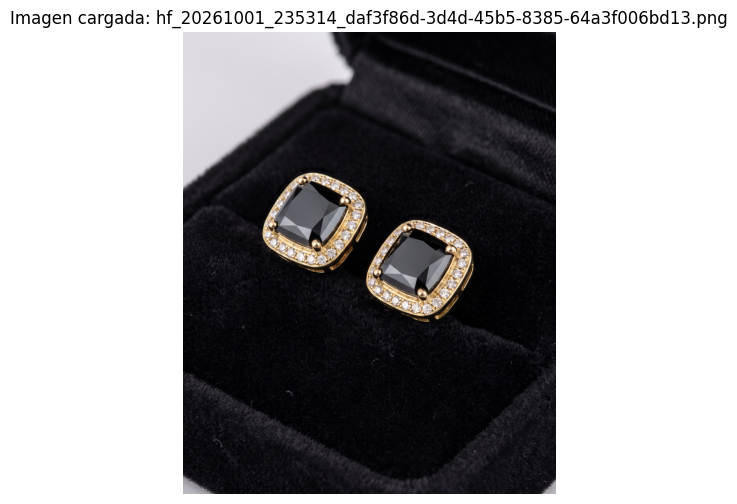


--- INSPECCIÓN DE DATOS ---
Ruta: hf_20261001_235314_daf3f86d-3d4d-45b5-8385-64a3f006bd13.png
Forma (Alto, Ancho, Canales): (2304, 1856, 3)
Tipo de dato: uint8
Valor mínimo: 0
Valor máximo: 255
Alto: 2304
Ancho: 1856
Píxel central BGR: [ 5  8 12]


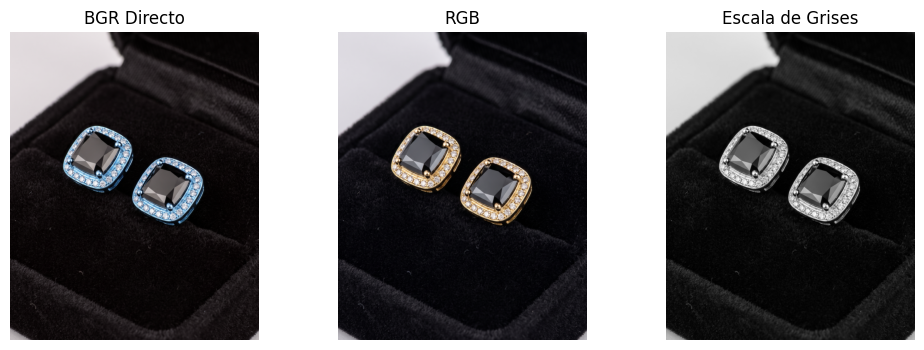

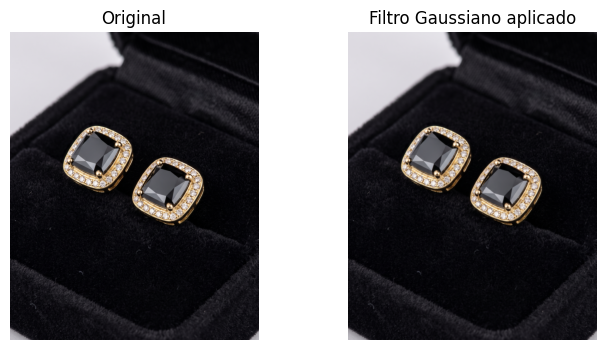

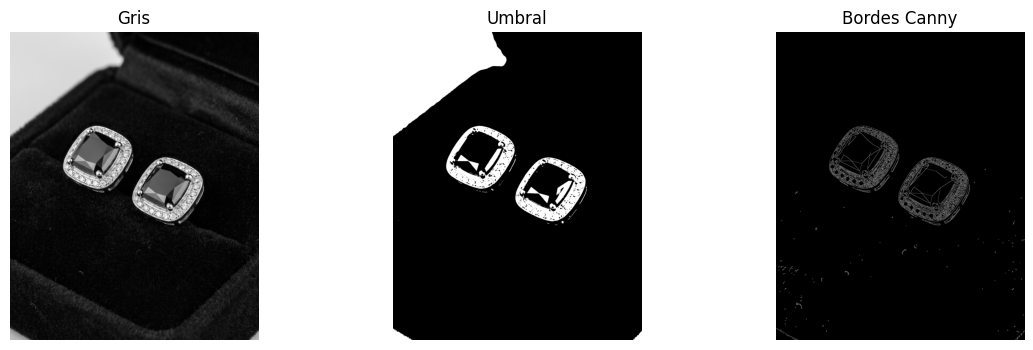

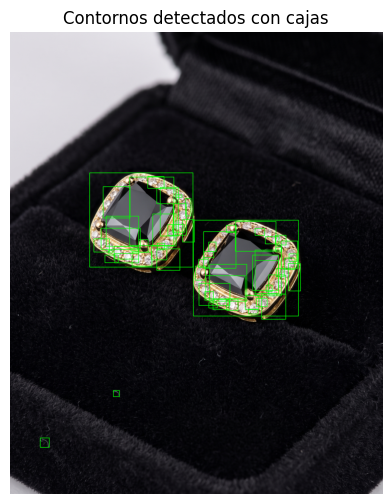


--- RESULTADOS FINALES DEL MINI RETO ---
Cantidad de contornos detectados: 900
Cantidad de contornos filtrados (>100px): 61
Áreas filtradas: [224.5, 221.5, 151.5, 122.0, 163.5, 134.5, 162.0, 257.0, 482.5, 109.0]


In [1]:
# ==============================================================================
# MINI RETO: FLUJO COMPLETO DE PERCEPCIÓN COMPUTACIONAL CON OPENCV
# Asignatura: Percepción Computacional
# Universidad de Cundinamarca
# ==============================================================================

# 1. IMPORTACIÓN DE LIBRERÍAS
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

print("Versión de OpenCV:", cv2.__version__)
print("Versión de NumPy:", np.__version__)

# Funciones auxiliares para mostrar imágenes correctamente
def mostrar(imagen, titulo="Imagen"):
    plt.figure(figsize=(6, 6))
    if len(imagen.shape) == 3:
        img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(imagen, cmap="gray")
    plt.title(titulo)
    plt.axis("off")
    plt.show()

# ------------------------------------------------------------------------------
# 2. CARGA DE UNA IMAGEN (Sube tu nueva imagen, ej. 'panda.jpg')
# ------------------------------------------------------------------------------
ruta_imagen = None

try:
    from google.colab import files
    print("Sube tu nueva imagen (ej. una foto diferente como un panda o un paisaje):")
    cargados = files.upload()
    if cargados:
        ruta_imagen = list(cargados.keys())[0]
except Exception as e:
    print("Aviso: No se detectó entorno Colab interactivo:", e)

# Si no subiste ninguna, puedes colocar el nombre de tu archivo manualmente aquí:
# ruta_imagen = "panda.jpg"

img = cv2.imread(ruta_imagen)

if img is None:
    raise ValueError("No se pudo cargar la imagen. Verifica que el archivo exista y sea válido.")

mostrar(img, f"Imagen cargada: {ruta_imagen}")

# ------------------------------------------------------------------------------
# 3. INSPECCIÓN DE LA IMAGEN COMO DATOS
# ------------------------------------------------------------------------------
print("\n--- INSPECCIÓN DE DATOS ---")
print("Ruta:", ruta_imagen)
print("Forma (Alto, Ancho, Canales):", img.shape)
print("Tipo de dato:", img.dtype)
print("Valor mínimo:", img.min())
print("Valor máximo:", img.max())

alto, ancho = img.shape[:2]
print("Alto:", alto)
print("Ancho:", ancho)
print("Píxel central BGR:", img[alto//2, ancho//2])

# ------------------------------------------------------------------------------
# 4. CONVERSIÓN A ESCALA DE GRISES Y COLOR
# ------------------------------------------------------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("BGR Directo")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gris, cmap="gray")
plt.title("Escala de Grises")
plt.axis("off")
plt.show()

# ------------------------------------------------------------------------------
# 5. FILTRADO Y REDUCCIÓN DE RUIDO
# ------------------------------------------------------------------------------
blur_gaussiano = cv2.GaussianBlur(img, (7, 7), 0)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(blur_gaussiano, cv2.COLOR_BGR2RGB))
plt.title("Filtro Gaussiano aplicado")
plt.axis("off")
plt.show()

# ------------------------------------------------------------------------------
# 6. UMBRALIZACIÓN Y DETECCIÓN DE BORDES (CANNY)
# ------------------------------------------------------------------------------
gris_suave = cv2.GaussianBlur(gris, (5, 5), 0)
_, umbral = cv2.threshold(gris_suave, 127, 255, cv2.THRESH_BINARY)
bordes = cv2.Canny(gris_suave, 80, 160)

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.imshow(gris, cmap="gray")
plt.title("Gris")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(umbral, cmap="gray")
plt.title("Umbral")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bordes, cmap="gray")
plt.title("Bordes Canny")
plt.axis("off")
plt.show()

# ------------------------------------------------------------------------------
# 7. EXTRACCIÓN DE CONTORNOS Y CAJAS DELIMITADORAS
# ------------------------------------------------------------------------------
contornos, _ = cv2.findContours(bordes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
resultado = img.copy()

areas = []
for c in contornos:
    area = cv2.contourArea(c)
    if area > 100:  # Filtra contornos pequeños
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(resultado, (x, y), (x + w, y + h), (0, 255, 0), 2)
        areas.append(area)

mostrar(resultado, "Contornos detectados con cajas")
print("\n--- RESULTADOS FINALES DEL MINI RETO ---")
print("Cantidad de contornos detectados:", len(contornos))
print("Cantidad de contornos filtrados (>100px):", len(areas))
print("Áreas filtradas:", areas[:10])